In [1]:
!pip install torch torchvision tqdm matplotlib pillow numpy scikit-learn tensorboard

   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/113.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/113.8 MB 1.9 MB/s eta 0:01:01
   ---------------------------------------- 1.0/113.8 MB 1.8 MB/s eta 0:01:03
   ---------------------------------------- 1.3/113.8 MB 1.8 MB/s eta 0:01:03
    --------------------------------------- 1.6/113.8 MB 1.8 MB/s eta 0:01:03
    --------------------------------------- 2.1/113.8 MB 1.8 MB/s eta 0:01:02
    --------------------------------------- 2.4/113.8 MB 1.8 MB/s eta 0:01:03
   - -------------------------------------- 2.9/113.8 MB 1.8 MB/s eta 0:01:02
   - -------------------------------------- 3.1/113.8 MB 1.8 MB/s eta 0:01:02
   - -------------------------------------- 3.4/113.8 MB 1.8 MB/s eta 0:01:02
   - -------------------------------------- 3.9/113.8 MB 1.8 MB/s eta 0:01:02
   - -------------------------------------- 4.2/113.8 MB 1.8 MB/s eta 0:01:01


In [1]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 5080 Laptop GPU


c:\Users\abilo\miniconda3\envs\dev\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5080 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5080 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [3]:
!pip uninstall torch torchvision torchaudio -y
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121


You can safely remove it manually.
You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 1.9 MB/s eta 0:25:10
   ---------------------------------------- 0.0/2.8 GB 1.9 MB/s eta 0:25:06
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:25:47
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:25:39
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:25:53
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:26:07
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:25:54
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:26:05
   ---------------------------------------- 0.0/2.8 GB 1.8 MB/s eta 0:26:00
   ---------------------------------------- 0.0/2

In [2]:
""" T92 Angle Prediction - Complete Training Pipeline
    
    Features:
    - Smart horizontal mirroring (doubles dataset with corrected labels)
    - Blur + noise augmentation for sim-to-real
    - Zenith-conditioned prediction
    - Sin/cos azimuth encoding
"""

import os
import csv
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm
import json
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ============================================
# CONFIGURATION
# ============================================
CONFIG = {
    # Paths
    'data_dir': Path(r'C:\development\msds_practicum\msds_practicum\data\raw'),
    'model_dir': Path(r'C:\development\msds_practicum\msds_practicum\models'),
    
    # Training
    'batch_size': 32,
    'epochs': 100,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'patience': 15,
    
    # Data
    'image_size': (224, 224),
    'train_split': 0.7,
    'val_split': 0.2,
    'test_split': 0.1,
    
    # Model
    'backbone': 'densenet121',
    'pretrained': True,
    'use_zenith_input': True,
    
    # Augmentation
    'use_mirroring': True,
    'blur_prob': 0.5,
    'blur_kernel_range': (3, 9),
    'noise_prob': 0.3,
    'noise_std_range': (0.01, 0.05),
    'grayscale_prob': 0.5,
}

CONFIG['model_dir'].mkdir(parents=True, exist_ok=True)


# ============================================
# CUSTOM AUGMENTATIONS
# ============================================
class RandomBlur:
    def __init__(self, p=0.5, kernel_range=(3, 7)):
        self.p = p
        self.kernel_range = kernel_range
    
    def __call__(self, img):
        if random.random() < self.p:
            k = random.choice(range(self.kernel_range[0], self.kernel_range[1] + 1, 2))
            return TF.gaussian_blur(img, kernel_size=k)
        return img


class RandomNoise:
    def __init__(self, p=0.3, std_range=(0.01, 0.05)):
        self.p = p
        self.std_range = std_range
    
    def __call__(self, tensor):
        if random.random() < self.p:
            std = random.uniform(*self.std_range)
            noise = torch.randn_like(tensor) * std
            return torch.clamp(tensor + noise, 0, 1)
        return tensor


# ============================================
# DATASET WITH SMART MIRRORING
# ============================================
class T92Dataset(Dataset):
    """
    When mirroring:
    - Image is flipped horizontally
    - Azimuth is transformed: new_azimuth = (360 - azimuth) % 360
    - Elevation stays the same
    - Zenith stays the same
    """
    
    def __init__(self, data_dir, transform=None, use_mirroring=True):
        self.image_paths = []
        self.azimuths = []
        self.elevations = []
        self.zeniths = []
        self.transform = transform
        self.use_mirroring = use_mirroring
        
        data_dir = Path(data_dir)
        
        elevation_folders = sorted([f for f in data_dir.iterdir() 
                                    if f.is_dir() and f.name.startswith('elev_')])
        
        print(f"Found {len(elevation_folders)} elevation folders")
        
        for folder in elevation_folders:
            csv_path = folder / 'labels.csv'
            if not csv_path.exists():
                print(f"  Warning: No labels.csv in {folder.name}")
                continue
            
            count = 0
            with open(csv_path, 'r') as f:
                reader = csv.DictReader(f)
                for row in reader:
                    img_path = folder / row['filename']
                    if img_path.exists():
                        self.image_paths.append(img_path)
                        self.azimuths.append(float(row['azimuth']))
                        self.elevations.append(float(row['elevation']))
                        self.zeniths.append(float(row['zenith']))
                        count += 1
            
            print(f"  {folder.name}: {count} images")
        
        self.azimuths = np.array(self.azimuths)
        self.elevations = np.array(self.elevations)
        self.zeniths = np.array(self.zeniths)
        
        self.base_length = len(self.image_paths)
        
        print(f"\nBase dataset: {self.base_length} images")
        if self.use_mirroring:
            print(f"With mirroring: {self.base_length * 2} effective images")
        print(f"  Azimuth: {self.azimuths.min():.1f} - {self.azimuths.max():.1f}")
        print(f"  Elevation: {self.elevations.min():.1f} - {self.elevations.max():.1f}")
        print(f"  Zenith: {self.zeniths.min():.1f} - {self.zeniths.max():.1f}")
    
    def __len__(self):
        if self.use_mirroring:
            return self.base_length * 2
        return self.base_length
    
    def __getitem__(self, idx):
        is_mirrored = False
        if self.use_mirroring and idx >= self.base_length:
            is_mirrored = True
            idx = idx - self.base_length
        
        image = Image.open(self.image_paths[idx]).convert('RGB')
        
        azimuth = self.azimuths[idx]
        elevation = self.elevations[idx]
        zenith = self.zeniths[idx]
        
        if is_mirrored:
            image = TF.hflip(image)
            azimuth = (360.0 - azimuth) % 360.0
        
        if self.transform:
            image = self.transform(image)
        
        az_rad = np.radians(azimuth)
        az_sin = np.sin(az_rad)
        az_cos = np.cos(az_rad)
        
        elev_norm = elevation / 90.0
        zenith_norm = zenith / 90.0
        
        target = torch.tensor([az_sin, az_cos, elev_norm], dtype=torch.float32)
        zenith_tensor = torch.tensor([zenith_norm], dtype=torch.float32)
        
        return image, zenith_tensor, target


# ============================================
# DATA TRANSFORMS
# ============================================
def get_train_transforms():
    return transforms.Compose([
        transforms.Resize(CONFIG['image_size']),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.15),
        transforms.RandomGrayscale(p=CONFIG['grayscale_prob']),
        RandomBlur(p=CONFIG['blur_prob'], kernel_range=CONFIG['blur_kernel_range']),
        transforms.ToTensor(),
        RandomNoise(p=CONFIG['noise_prob'], std_range=CONFIG['noise_std_range']),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def get_val_transforms():
    return transforms.Compose([
        transforms.Resize(CONFIG['image_size']),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


# ============================================
# MODEL
# ============================================
class T92AnglePredictor(nn.Module):
    def __init__(self, backbone='densenet121', pretrained=True, use_zenith_input=True):
        super().__init__()
        
        self.use_zenith_input = use_zenith_input
        
        if backbone == 'densenet121':
            weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            self.backbone = models.densenet121(weights=weights)
            num_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
        
        elif backbone == 'resnet50':
            weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
            self.backbone = models.resnet50(weights=weights)
            num_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        
        if use_zenith_input:
            num_features += 1
        
        self.head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 3)
        )
    
    def forward(self, image, zenith=None):
        features = self.backbone(image)
        
        if self.use_zenith_input and zenith is not None:
            features = torch.cat([features, zenith], dim=1)
        
        return self.head(features)


# ============================================
# LOSS AND METRICS
# ============================================
class AngleLoss(nn.Module):
    def __init__(self, azimuth_weight=1.0, elevation_weight=1.0):
        super().__init__()
        self.azimuth_weight = azimuth_weight
        self.elevation_weight = elevation_weight
    
    def forward(self, pred, target):
        az_loss = nn.functional.mse_loss(pred[:, :2], target[:, :2])
        elev_loss = nn.functional.mse_loss(pred[:, 2], target[:, 2])
        return self.azimuth_weight * az_loss + self.elevation_weight * elev_loss


def compute_errors(pred, target):
    with torch.no_grad():
        pred_az = torch.rad2deg(torch.atan2(pred[:, 0], pred[:, 1])) % 360
        target_az = torch.rad2deg(torch.atan2(target[:, 0], target[:, 1])) % 360
        
        az_error = torch.abs(pred_az - target_az)
        az_error = torch.min(az_error, 360 - az_error)
        
        pred_elev = pred[:, 2] * 90
        target_elev = target[:, 2] * 90
        elev_error = torch.abs(pred_elev - target_elev)
        
        return {
            'azimuth_mae': az_error.mean().item(),
            'elevation_mae': elev_error.mean().item(),
            'pred_az': pred_az,
            'pred_elev': pred_elev,
            'target_az': target_az,
            'target_elev': target_elev
        }


# ============================================
# TRAINING FUNCTIONS
# ============================================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_az_err = 0
    total_elev_err = 0
    count = 0
    
    pbar = tqdm(loader, desc="Train", leave=False)
    for images, zeniths, targets in pbar:
        images = images.to(device)
        zeniths = zeniths.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images, zeniths)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        errors = compute_errors(outputs, targets)
        
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_az_err += errors['azimuth_mae'] * bs
        total_elev_err += errors['elevation_mae'] * bs
        count += bs
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'az': f'{errors["azimuth_mae"]:.1f}',
            'el': f'{errors["elevation_mae"]:.1f}'
        })
    
    return {
        'loss': total_loss / count,
        'azimuth_mae': total_az_err / count,
        'elevation_mae': total_elev_err / count
    }


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_az_err = 0
    total_elev_err = 0
    count = 0
    
    all_pred_az = []
    all_pred_elev = []
    all_target_az = []
    all_target_elev = []
    
    with torch.no_grad():
        for images, zeniths, targets in tqdm(loader, desc="Val", leave=False):
            images = images.to(device)
            zeniths = zeniths.to(device)
            targets = targets.to(device)
            
            outputs = model(images, zeniths)
            loss = criterion(outputs, targets)
            
            errors = compute_errors(outputs, targets)
            
            bs = images.size(0)
            total_loss += loss.item() * bs
            total_az_err += errors['azimuth_mae'] * bs
            total_elev_err += errors['elevation_mae'] * bs
            count += bs
            
            all_pred_az.extend(errors['pred_az'].cpu().tolist())
            all_pred_elev.extend(errors['pred_elev'].cpu().tolist())
            all_target_az.extend(errors['target_az'].cpu().tolist())
            all_target_elev.extend(errors['target_elev'].cpu().tolist())
    
    return {
        'loss': total_loss / count,
        'azimuth_mae': total_az_err / count,
        'elevation_mae': total_elev_err / count,
        'predictions': {
            'pred_az': all_pred_az,
            'pred_elev': all_pred_elev,
            'target_az': all_target_az,
            'target_elev': all_target_elev
        }
    }


# ============================================
# SUBSET WRAPPER
# ============================================
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform, use_mirroring=True):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
        self.use_mirroring = use_mirroring
        self.base_length = dataset.base_length
    
    def __len__(self):
        if self.use_mirroring:
            return len(self.indices) * 2
        return len(self.indices)
    
    def __getitem__(self, idx):
        is_mirrored = False
        if self.use_mirroring and idx >= len(self.indices):
            is_mirrored = True
            idx = idx - len(self.indices)
        
        real_idx = self.indices[idx]
        
        image = Image.open(self.dataset.image_paths[real_idx]).convert('RGB')
        
        azimuth = self.dataset.azimuths[real_idx]
        elevation = self.dataset.elevations[real_idx]
        zenith = self.dataset.zeniths[real_idx]
        
        if is_mirrored:
            image = TF.hflip(image)
            azimuth = (360.0 - azimuth) % 360.0
        
        if self.transform:
            image = self.transform(image)
        
        az_rad = np.radians(azimuth)
        target = torch.tensor([
            np.sin(az_rad),
            np.cos(az_rad),
            elevation / 90.0
        ], dtype=torch.float32)
        
        zenith_tensor = torch.tensor([zenith / 90.0], dtype=torch.float32)
        
        return image, zenith_tensor, target


# ============================================
# PLOTTING
# ============================================
def plot_training_curves(history, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    epochs = range(1, len(history['train']) + 1)
    
    axes[0].plot(epochs, [h['loss'] for h in history['train']], label='Train')
    axes[0].plot(epochs, [h['loss'] for h in history['val']], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(epochs, [h['azimuth_mae'] for h in history['train']], label='Train')
    axes[1].plot(epochs, [h['azimuth_mae'] for h in history['val']], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE (degrees)')
    axes[1].set_title('Azimuth Error')
    axes[1].legend()
    axes[1].grid(True)
    
    axes[2].plot(epochs, [h['elevation_mae'] for h in history['train']], label='Train')
    axes[2].plot(epochs, [h['elevation_mae'] for h in history['val']], label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAE (degrees)')
    axes[2].set_title('Elevation Error')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


def plot_predictions(predictions, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].scatter(predictions['target_az'], predictions['pred_az'], alpha=0.1, s=1)
    axes[0].plot([0, 360], [0, 360], 'r--', linewidth=2)
    axes[0].set_xlabel('True Azimuth')
    axes[0].set_ylabel('Predicted Azimuth')
    axes[0].set_title('Azimuth Predictions')
    axes[0].set_xlim(0, 360)
    axes[0].set_ylim(0, 360)
    axes[0].grid(True)
    
    axes[1].scatter(predictions['target_elev'], predictions['pred_elev'], alpha=0.1, s=1)
    axes[1].plot([0, 90], [0, 90], 'r--', linewidth=2)
    axes[1].set_xlabel('True Elevation')
    axes[1].set_ylabel('Predicted Elevation')
    axes[1].set_title('Elevation Predictions')
    axes[1].set_xlim(0, 90)
    axes[1].set_ylim(0, 90)
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()


# ============================================
# MAIN TRAINING
# ============================================
def train():
    print("=" * 60)
    print("T92 ANGLE PREDICTION TRAINING")
    print("=" * 60)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nDevice: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    
    print("\nLoading dataset...")
    full_dataset = T92Dataset(
        CONFIG['data_dir'], 
        transform=None, 
        use_mirroring=False
    )
    
    if len(full_dataset) == 0:
        print("ERROR: No data found!")
        return None
    
    total = full_dataset.base_length
    indices = list(range(total))
    
    train_indices, temp_indices = train_test_split(
        indices, 
        test_size=(CONFIG['val_split'] + CONFIG['test_split']),
        random_state=42
    )
    
    val_ratio = CONFIG['val_split'] / (CONFIG['val_split'] + CONFIG['test_split'])
    val_indices, test_indices = train_test_split(
        temp_indices,
        test_size=(1 - val_ratio),
        random_state=42
    )
    
    print(f"\nBase split: {len(train_indices)} train, {len(val_indices)} val, {len(test_indices)} test")
    
    train_ds = TransformSubset(
        full_dataset, train_indices, 
        get_train_transforms(), 
        use_mirroring=CONFIG['use_mirroring']
    )
    
    val_ds = TransformSubset(
        full_dataset, val_indices,
        get_val_transforms(),
        use_mirroring=False
    )
    
    test_ds = TransformSubset(
        full_dataset, test_indices,
        get_val_transforms(),
        use_mirroring=False
    )
    
    print(f"Effective sizes: {len(train_ds)} train, {len(val_ds)} val, {len(test_ds)} test")
    
    num_workers = 0 if os.name == 'nt' else 4
    
    train_loader = DataLoader(
        train_ds, batch_size=CONFIG['batch_size'], shuffle=True,
        num_workers=num_workers, pin_memory=True
    )
    val_loader = DataLoader(
        val_ds, batch_size=CONFIG['batch_size'], shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=CONFIG['batch_size'], shuffle=False,
        num_workers=num_workers, pin_memory=True
    )
    
    print(f"\nCreating model: {CONFIG['backbone']}")
    model = T92AnglePredictor(
        backbone=CONFIG['backbone'],
        pretrained=CONFIG['pretrained'],
        use_zenith_input=CONFIG['use_zenith_input']
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {total_params:,}")
    
    criterion = AngleLoss()
    optimizer = optim.AdamW(
        model.parameters(), 
        lr=CONFIG['learning_rate'], 
        weight_decay=CONFIG['weight_decay']
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train': [], 'val': []}
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = f"t92_{CONFIG['backbone']}_{timestamp}"
    best_model_path = CONFIG['model_dir'] / f"{model_name}_best.pt"
    
    print(f"\nTraining for up to {CONFIG['epochs']} epochs...")
    print(f"Mirroring: {CONFIG['use_mirroring']}")
    print("=" * 60)
    
    for epoch in range(CONFIG['epochs']):
        print(f"\nEpoch {epoch + 1}/{CONFIG['epochs']}")
        print("-" * 40)
        
        train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = validate(model, val_loader, criterion, device)
        
        scheduler.step(val_metrics['loss'])
        
        print(f"Train | Loss: {train_metrics['loss']:.4f} | Az: {train_metrics['azimuth_mae']:.2f} | El: {train_metrics['elevation_mae']:.2f}")
        print(f"Val   | Loss: {val_metrics['loss']:.4f} | Az: {val_metrics['azimuth_mae']:.2f} | El: {val_metrics['elevation_mae']:.2f}")
        
        history['train'].append({
            'loss': train_metrics['loss'],
            'azimuth_mae': train_metrics['azimuth_mae'],
            'elevation_mae': train_metrics['elevation_mae']
        })
        history['val'].append({
            'loss': val_metrics['loss'],
            'azimuth_mae': val_metrics['azimuth_mae'],
            'elevation_mae': val_metrics['elevation_mae']
        })
        
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            patience_counter = 0
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_metrics': {
                    'loss': val_metrics['loss'],
                    'azimuth_mae': val_metrics['azimuth_mae'],
                    'elevation_mae': val_metrics['elevation_mae']
                },
                'config': {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
            }, best_model_path)
            
            print("Saved best model")
        else:
            patience_counter += 1
            print(f"No improvement ({patience_counter}/{CONFIG['patience']})")
            
            if patience_counter >= CONFIG['patience']:
                print("\nEarly stopping!")
                break
    
    print("\n" + "=" * 60)
    print("TEST EVALUATION")
    print("=" * 60)
    
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    test_metrics = validate(model, test_loader, criterion, device)
    
    print(f"\nTest Results:")
    print(f"  Loss:          {test_metrics['loss']:.4f}")
    print(f"  Azimuth MAE:   {test_metrics['azimuth_mae']:.2f}")
    print(f"  Elevation MAE: {test_metrics['elevation_mae']:.2f}")
    
    curves_path = CONFIG['model_dir'] / f"{model_name}_curves.png"
    plot_training_curves(history, curves_path)
    print(f"\n  Curves: {curves_path}")
    
    predictions_path = CONFIG['model_dir'] / f"{model_name}_predictions.png"
    plot_predictions(test_metrics['predictions'], predictions_path)
    print(f"  Predictions: {predictions_path}")
    
    history_path = CONFIG['model_dir'] / f"{model_name}_history.json"
    with open(history_path, 'w') as f:
        json.dump({
            'config': {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
            'history': history,
            'test_metrics': {
                'loss': test_metrics['loss'],
                'azimuth_mae': test_metrics['azimuth_mae'],
                'elevation_mae': test_metrics['elevation_mae']
            }
        }, f, indent=2)
    print(f"  History: {history_path}")
    
    print(f"\n  Model: {best_model_path}")
    
    return model


# ============================================
# INFERENCE
# ============================================
def predict(image_path, zenith_deg, model_path=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if model_path is None:
        model_files = list(CONFIG['model_dir'].glob("*_best.pt"))
        if not model_files:
            raise FileNotFoundError("No saved models found")
        model_path = max(model_files, key=lambda p: p.stat().st_mtime)
        print(f"Using model: {model_path.name}")
    
    checkpoint = torch.load(model_path, map_location=device)
    model = T92AnglePredictor(
        backbone=CONFIG['backbone'],
        pretrained=False,
        use_zenith_input=CONFIG['use_zenith_input']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    transform = get_val_transforms()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0).to(device)
    
    zenith = torch.tensor([[zenith_deg / 90.0]], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        output = model(image, zenith)
    
    azimuth = torch.rad2deg(torch.atan2(output[0, 0], output[0, 1])).item() % 360
    elevation = output[0, 2].item() * 90
    
    return {
        'azimuth': round(azimuth, 2),
        'elevation': round(elevation, 2)
    }


# ============================================
# RUN
# ============================================
if __name__ == "__main__":
    model = train()

T92 ANGLE PREDICTION TRAINING

Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU

Loading dataset...
Found 19 elevation folders
  elev_00: 3600 images
  elev_05: 3600 images
  elev_10: 3600 images
  elev_15: 3600 images
  elev_20: 3600 images
  elev_25: 3600 images
  elev_30: 3600 images
  elev_35: 3600 images
  elev_40: 3600 images
  elev_45: 3600 images
  elev_50: 3571 images
  elev_55: 3600 images
  elev_60: 3600 images
  elev_65: 3600 images
  elev_70: 3600 images
  elev_75: 3600 images
  elev_80: 3600 images
  elev_85: 3600 images
  elev_90: 3600 images

Base dataset: 68371 images
  Azimuth: 0.0 - 360.0
  Elevation: 0.0 - 90.0
  Zenith: 1.0 - 89.0

Base split: 47859 train, 13674 val, 6838 test
Effective sizes: 95718 train, 13674 val, 6838 test

Creating model: densenet121
Parameters: 7,611,267

Training for up to 100 epochs...
Mirroring: True

Epoch 1/100
----------------------------------------


Train | Loss: 0.1033 | Az: 15.32 | El: 9.35
Val   | Loss: 0.0578 | Az: 11.10 | El: 5.51
Saved best model

Epoch 2/100
----------------------------------------


Train | Loss: 0.0636 | Az: 11.03 | El: 7.00
Val   | Loss: 0.0444 | Az: 9.78 | El: 3.77
Saved best model

Epoch 3/100
----------------------------------------


Train | Loss: 0.0534 | Az: 9.99 | El: 6.20
Val   | Loss: 0.0374 | Az: 7.82 | El: 3.69
Saved best model

Epoch 4/100
----------------------------------------


Train | Loss: 0.0448 | Az: 8.90 | El: 5.71
Val   | Loss: 0.0327 | Az: 7.75 | El: 4.06
Saved best model

Epoch 5/100
----------------------------------------


Train | Loss: 0.0389 | Az: 8.08 | El: 5.33
Val   | Loss: 0.0229 | Az: 5.99 | El: 2.66
Saved best model

Epoch 6/100
----------------------------------------


Train | Loss: 0.0333 | Az: 7.28 | El: 5.05
Val   | Loss: 0.0196 | Az: 5.57 | El: 3.55
Saved best model

Epoch 7/100
----------------------------------------


Train | Loss: 0.0289 | Az: 6.60 | El: 4.85
Val   | Loss: 0.0172 | Az: 4.83 | El: 2.92
Saved best model

Epoch 8/100
----------------------------------------


KeyboardInterrupt: 

Loading: t92_densenet121_20260128_190120_best.pt

Found 20 images in C:\development\msds_practicum\msds_practicum\data\real_test
Using zenith estimate: 12 degrees
All images resized to 224x224

------------------------------------------------------------
Filename                       | Original     |     Az |    El
------------------------------------------------------------
Screenshot 2026-01-28 195642.png | 316x316      |  105.7 |  23.5
Screenshot 2026-01-28 195642.png | 316x316      |  105.7 |  23.5
Screenshot 2026-01-28 195711.png | 316x318      |  289.1 |  41.3
Screenshot 2026-01-28 195711.png | 316x318      |  289.1 |  41.3
Screenshot 2026-01-28 195734.png | 318x318      |   73.2 |  68.2
Screenshot 2026-01-28 195734.png | 318x318      |   73.2 |  68.2
Screenshot 2026-01-28 195849.png | 316x318      |  187.7 |  58.4
Screenshot 2026-01-28 195849.png | 316x318      |  187.7 |  58.4
Screenshot 2026-01-28 195920.png | 316x316      |  286.9 |   8.9
Screenshot 2026-01-28 195920.png | 3

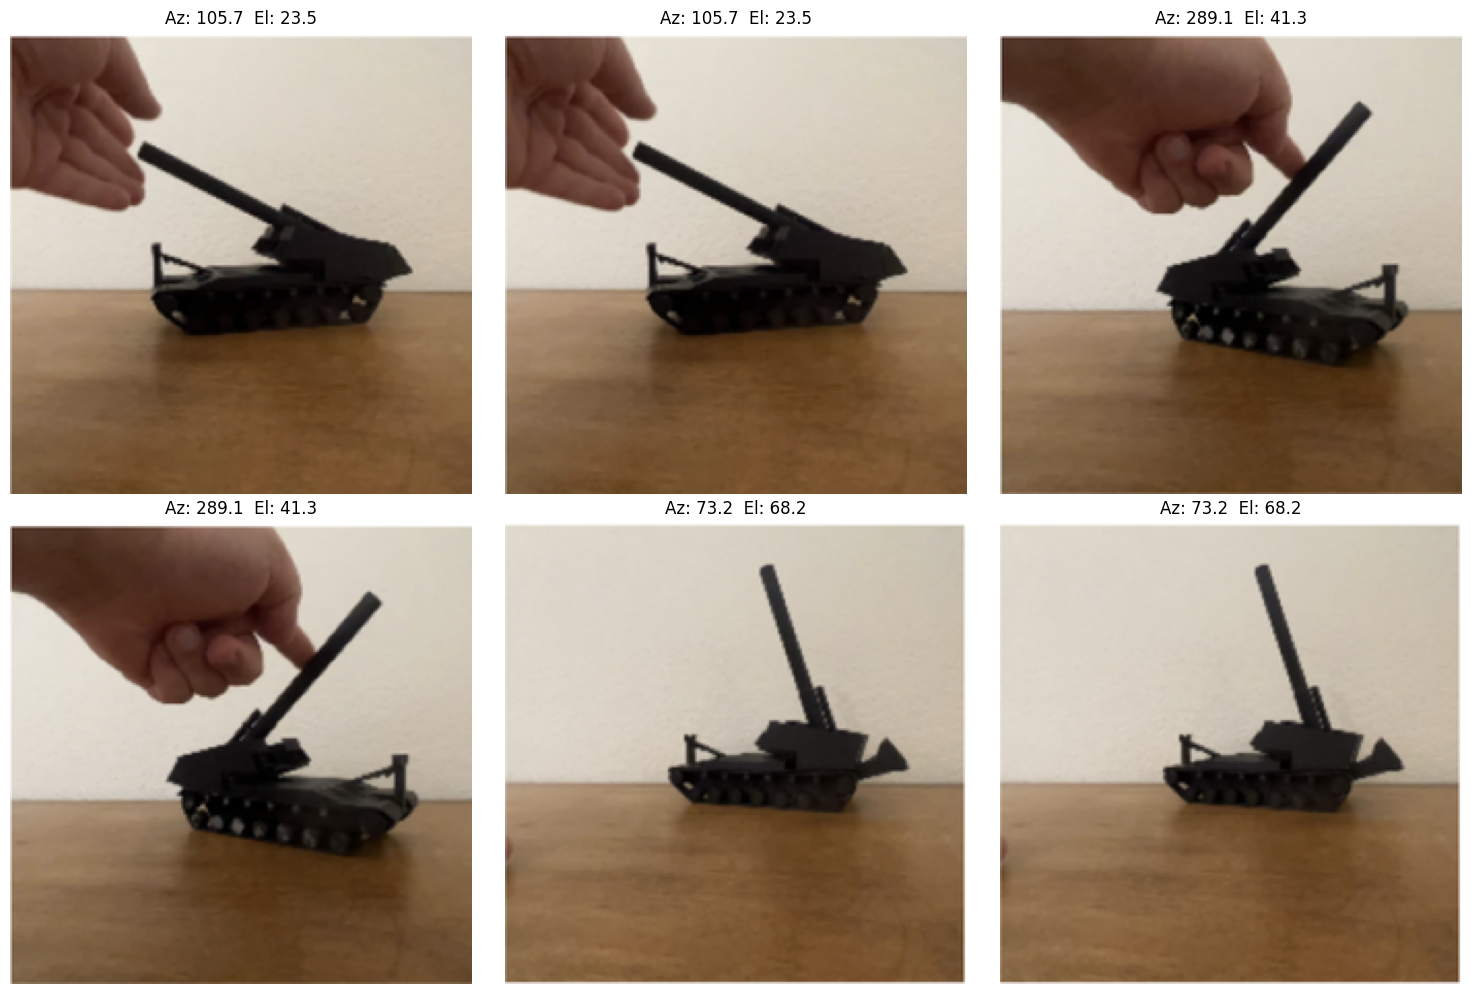


Saved visualization to C:\development\msds_practicum\msds_practicum\data\real_test\predictions_visualization.png


In [8]:
""" Test T92 Model on Real Images
"""

import torch
from pathlib import Path
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

# ============================================
# CONFIGURATION
# ============================================
MODEL_DIR = Path(r'C:\development\msds_practicum\msds_practicum\models')
TEST_IMAGES_DIR = Path(r'C:\development\msds_practicum\msds_practicum\data\real_test')

# ============================================
# LOAD MODEL
# ============================================
def load_model(model_path=None):
    from torchvision import models
    import torch.nn as nn
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    if model_path is None:
        model_files = list(MODEL_DIR.glob("*_best.pt"))
        if not model_files:
            raise FileNotFoundError("No saved models found")
        model_path = max(model_files, key=lambda p: p.stat().st_mtime)
    
    print(f"Loading: {model_path.name}")
    checkpoint = torch.load(model_path, map_location=device)
    
    class T92AnglePredictor(nn.Module):
        def __init__(self):
            super().__init__()
            self.backbone = models.densenet121(weights=None)
            num_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
            
            self.head = nn.Sequential(
                nn.Linear(num_features + 1, 512),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(256, 3)
            )
        
        def forward(self, image, zenith):
            features = self.backbone(image)
            features = torch.cat([features, zenith], dim=1)
            return self.head(features)
    
    model = T92AnglePredictor()
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    return model, device


# ============================================
# INFERENCE
# ============================================
def get_transform():
    """Force resize to exactly 224x224"""
    return transforms.Compose([
        transforms.Resize((224, 224), antialias=True),  # Force exact size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


def predict_single(model, image_path, zenith_deg, device):
    """
    Predict azimuth and elevation for one image.
    """
    transform = get_transform()
    
    # Load and force RGB
    image = Image.open(image_path).convert('RGB')
    original_size = image.size
    
    # Force resize to 224x224 (in case transform doesn't catch it)
    image = image.resize((224, 224), Image.LANCZOS)
    
    # Apply transforms
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Verify shape
    assert image_tensor.shape == (1, 3, 224, 224), f"Wrong shape: {image_tensor.shape}"
    
    zenith = torch.tensor([[zenith_deg / 90.0]], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        output = model(image_tensor, zenith)
    
    azimuth = torch.rad2deg(torch.atan2(output[0, 0], output[0, 1])).item() % 360
    elevation = output[0, 2].item() * 90
    
    return {
        'azimuth': round(azimuth, 1),
        'elevation': round(elevation, 1),
        'original_size': original_size
    }


def predict_folder(model, folder_path, zenith_deg, device):
    """
    Predict on all images in a folder.
    """
    folder = Path(folder_path)
    results = []
    
    image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(folder.glob(ext))
    
    print(f"\nFound {len(image_paths)} images in {folder}")
    print(f"Using zenith estimate: {zenith_deg} degrees")
    print(f"All images resized to 224x224\n")
    print("-" * 60)
    print(f"{'Filename':30s} | {'Original':12s} | {'Az':>6s} | {'El':>5s}")
    print("-" * 60)
    
    for img_path in sorted(image_paths):
        pred = predict_single(model, img_path, zenith_deg, device)
        results.append({
            'filename': img_path.name,
            'azimuth': pred['azimuth'],
            'elevation': pred['elevation'],
            'original_size': pred['original_size']
        })
        orig = f"{pred['original_size'][0]}x{pred['original_size'][1]}"
        print(f"{img_path.name:30s} | {orig:12s} | {pred['azimuth']:6.1f} | {pred['elevation']:5.1f}")
    
    print("-" * 60)
    return results


def visualize_predictions(model, folder_path, zenith_deg, device, num_images=6):
    """
    Show images with predictions overlaid.
    """
    folder = Path(folder_path)
    
    image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.PNG', '*.JPG', '*.JPEG']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(folder.glob(ext))
    
    image_paths = sorted(image_paths)[:num_images]
    
    cols = min(3, len(image_paths))
    rows = (len(image_paths) + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if len(image_paths) == 1:
        axes = [axes]
    elif rows == 1:
        axes = list(axes)
    else:
        axes = axes.flatten()
    
    for i, img_path in enumerate(image_paths):
        pred = predict_single(model, img_path, zenith_deg, device)
        
        # Show the 224x224 version (what the model sees)
        img = Image.open(img_path).convert('RGB').resize((224, 224), Image.LANCZOS)
        axes[i].imshow(img)
        axes[i].set_title(f"Az: {pred['azimuth']:.1f}  El: {pred['elevation']:.1f}", fontsize=12)
        axes[i].axis('off')
    
    for i in range(len(image_paths), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    save_path = folder / 'predictions_visualization.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"\nSaved visualization to {save_path}")


# ============================================
# MAIN
# ============================================
if __name__ == "__main__":
    # Load model
    model, device = load_model()
    
    # Set your test images folder
    test_folder = TEST_IMAGES_DIR
    
    # Estimate zenith angle for your real images
    # - Ground level photo: 10-30
    # - Slightly elevated (standing): 30-45  
    # - Drone/aerial: 45-75
    estimated_zenith = 12
    
    # Run predictions
    results = predict_folder(model, test_folder, estimated_zenith, device)
    
    # Visualize
    visualize_predictions(model, test_folder, estimated_zenith, device)